# Wide Binary Coordinates in TRACE

We setup a simulation of the outer solar system and increase the masses of the planets by a factor of 50. We also add a binary companion on a 300 AU orbit. In WB coordinates, the wide binary companion must the LAST massive particle you add!! Otherwise the code will completely fail. 

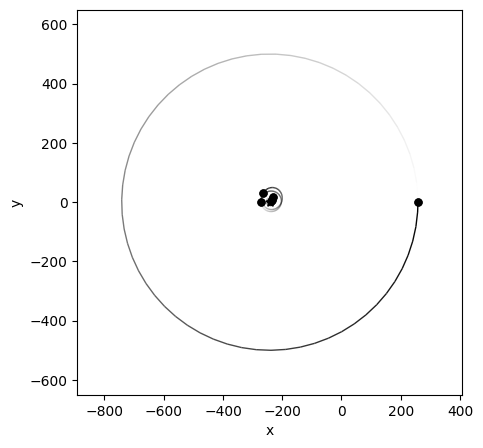

In [9]:
import math
import rebound, rebound.data
%matplotlib inline
sim = rebound.Simulation()
rebound.data.add_outer_solar_system(sim) # add some particles for testing
for i in range(1,sim.N):
    sim.particles[i].m *= 50.

sim.add(m=1., a=500.) # add a wide binary companion
sim.integrator = "TRACE" # This will end badly!
sim.ri_trace.coordinates = "widebinary"
sim.dt = sim.particles[1].P * 0.002 # Timestep a small fraction of innermost planet's period
sim.move_to_com()
E0 = sim.energy() # Calculate initial energy 
rebound.OrbitPlot(sim);

Let us integrate this system for a few hundred years. An instability will occur. We can then measure the energy error, which is a good estimate as to how accurate the integration was.

Relative energy error with TRACE: -0.000002


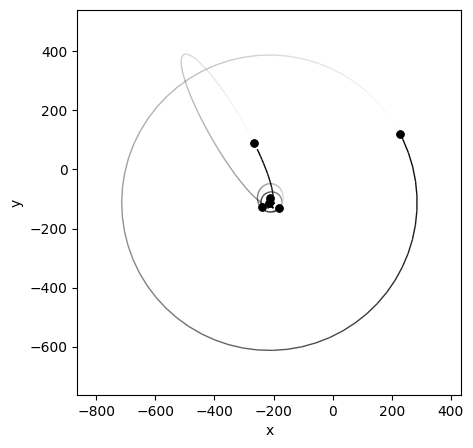

In [12]:
sim.integrate(600*2.*math.pi)
E1 = sim.energy()
rebound.OrbitPlot(sim);
print("Relative energy error with TRACE: %f"%((E0-E1)/E0))

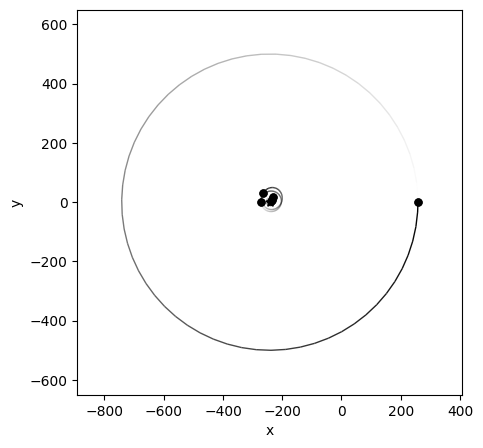

In [13]:
import math
import rebound, rebound.data
%matplotlib inline
sim = rebound.Simulation()
rebound.data.add_outer_solar_system(sim) # add some particles for testing
for i in range(1,sim.N):
    sim.particles[i].m *= 50.

sim.add(m=1., a=500.) # add a wide binary companion
sim.integrator = "TRACE" # This will end badly!
#sim.ri_trace.coordinates = "widebinary"
#sim.ri_trace.r_crit_WB = 1.0
sim.dt = sim.particles[1].P * 0.002 # Timestep a small fraction of innermost planet's period
sim.move_to_com()
E0 = sim.energy() # Calculate initial energy 
rebound.OrbitPlot(sim);

An energy error that large means we basically go it wrong completely. Let's try this again but use TRACE.